# SimCLR Self-Supervised Pretraining on STL-10

Pretrains a ResNet-18 encoder on STL-10 unlabelled images using the SimCLR
contrastive objective (NT-Xent loss). The encoder is saved for FixMatch fine-tuning.

**Full run** (20 epochs, ~70 min on Kaggle T4): `SMOKE_TEST = False`  
**Quick sanity check** (~2 min, CPU/low-disk): `SMOKE_TEST = True`

## Actual results (Kaggle T4, 20 epochs)

| Metric | Value |
|---|---|
| GPU | Tesla T4 (sm_75) |
| Unlabelled images | 100,000 |
| Epochs trained | 20 |
| Batches/epoch | 390 |
| NT-Xent loss (epoch 1 → 20) | 6.22 → ~4.8 |
| Linear probe accuracy | **55.5%** |
| Encoder checkpoint | `simclr_encoder.pt` (44.8 MB) |

In [1]:
from kaggle_secrets import UserSecretsClient

token = UserSecretsClient().get_secret("GITHUB_TOKEN")
!git clone https://{token}@github.com/dima806/semi_supervised_image_clf.git

Cloning into 'semi_supervised_image_clf'...
remote: Enumerating objects: 101, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 101 (delta 35), reused 86 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (101/101), 232.28 KiB | 2.73 MiB/s, done.
Resolving deltas: 100% (35/35), done.


In [2]:
!pip install --no-deps git+https://{token}@github.com/dima806/semi_supervised_image_clf.git

  Cloning https://****@github.com/dima806/semi_supervised_image_clf.git to /tmp/pip-req-build-z7v1ooqi
  Running command git clone --filter=blob:none --quiet 'https://****@github.com/dima806/semi_supervised_image_clf.git' /tmp/pip-req-build-z7v1ooqi
  Resolved https://****@github.com/dima806/semi_supervised_image_clf.git to commit b211855c07d7f961677653a504988233555a1727
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for semi-supervised-image-clf: filename=semi_supervised_image_clf-0.1.0-py3-none-any.whl size=27268 sha256=3a8044e9689f7e369f9ca9158e9d89658a9989f769ae6239afb7c01826b3727a
  Stored in directory: /tmp/pip-ephem-wheel-cache-1k6goceb/wheels/cf/26/7d/5d2cba3c00f664a1ba559afa231865f6ce72885510d0f7f109
Successfully built semi-supervised-image-clf


In [3]:
!pip install mlflow loguru

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 101.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 15.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behav

In [4]:
# Disable MLflow tracking globally (affects all internal training calls)
import mlflow

class _NoOpRun:
    def __enter__(self): return self
    def __exit__(self, *a): pass

mlflow.set_experiment = lambda *a, **kw: None
mlflow.start_run     = lambda *a, **kw: _NoOpRun()
mlflow.log_params    = lambda *a, **kw: None
mlflow.log_param     = lambda *a, **kw: None
mlflow.log_metric    = lambda *a, **kw: None
mlflow.log_metrics   = lambda *a, **kw: None
mlflow.end_run       = lambda *a, **kw: None
print('MLflow tracking disabled.')

MLflow tracking disabled.


In [5]:
import torch
print(f'torch version:    {torch.__version__}')
print(f'CUDA available:   {torch.cuda.is_available()}')
if torch.cuda.is_available():
    cc = torch.cuda.get_device_capability()
    print(f'GPU:              {torch.cuda.get_device_name(0)}')
    print(f'Compute cap:      sm_{cc[0]}{cc[1]}')
    # Verify a kernel actually runs on this device
    try:
        x = torch.ones(4, 4).cuda()
        _ = torch.nn.BatchNorm1d(4).cuda()(x)
        print('Kernel smoke test: PASSED')
    except Exception as e:
        print(f'Kernel smoke test: FAILED — {e}')

torch version:    2.10.0+cu128
CUDA available:   True
GPU:              Tesla T4
Compute cap:      sm_75
Kernel smoke test: PASSED


## 1. Configuration

In [6]:
# ── Set to True for a fast local sanity-check (uses < 200 MB of data) ──────
SMOKE_TEST = False # True
# ────────────────────────────────────────────────────────────────────────────

DATA_DIR       = '/kaggle/working/data/'
CHECKPOINT_DIR = '/kaggle/working/checkpoints/'

# Smoke-test caps (ignored when SMOKE_TEST = False)
SMOKE_MAX_UNLABELLED = 1_000   # images used for pretraining
SMOKE_MAX_LABELLED   = 200     # images used for linear probe
SMOKE_EPOCHS         = 2

print(f'SMOKE_TEST = {SMOKE_TEST}')

SMOKE_TEST = False


## 2. Environment setup

In [7]:
import subprocess, sys
print(subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout or 'No GPU.')
print('Environment ready.')

Mon Apr  6 16:04:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P0             25W /   70W |     123MiB /  15360MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
from pathlib import Path

import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets

from semi_supervised_image_clf.config import load_simclr_config
from semi_supervised_image_clf.model import ResNet18WithProjection
from semi_supervised_image_clf.simclr import SimCLRDataset, train_simclr

Path(DATA_DIR).mkdir(parents=True, exist_ok=True)
Path(CHECKPOINT_DIR).mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}' + (f'  GPU: {torch.cuda.get_device_name(0)}' if DEVICE == 'cuda' else ''))

Device: cuda  GPU: Tesla T4


## 3. Download data

In [9]:
# Only the unlabelled split is needed for pretraining (~2.5 GB full / ~25 MB smoke)
print('Downloading STL-10 unlabelled split...')
unlabelled_raw = datasets.STL10(root=DATA_DIR, split='unlabeled', download=True)
print(f'Total unlabelled images: {len(unlabelled_raw):,}')

if SMOKE_TEST:
    unlabelled_raw = Subset(unlabelled_raw, list(range(SMOKE_MAX_UNLABELLED)))
    print(f'Smoke test: using first {len(unlabelled_raw):,} images')

100%|██████████| 2.64G/2.64G [02:55<00:00, 15.0MB/s] 


Total unlabelled images: 100,000


## 4. Build SimCLR loader & model

In [10]:
config = load_simclr_config('semi_supervised_image_clf/config/simclr.yaml')

if SMOKE_TEST:
    config.training.epochs     = SMOKE_EPOCHS
    config.training.batch_size = 32
    config.training.warmup_epochs = 0
    config.data.num_workers    = 2
else:
    config.training.batch_size = 256
    config.data.num_workers    = 4
    config.training.epochs     = 20 # DI: used fewer epochs to get faster results

simclr_ds = SimCLRDataset(unlabelled_raw, input_size=config.model.input_size)
simclr_loader = DataLoader(
    simclr_ds,
    batch_size=config.training.batch_size,
    shuffle=True,
    num_workers=config.data.num_workers,
    pin_memory=(DEVICE == 'cuda'),
    drop_last=True,
)

model = ResNet18WithProjection(projection_dim=config.model.projection_dim)

print(f'Dataset:       {len(simclr_ds):,} images')
print(f'Batches/epoch: {len(simclr_loader):,}')
print(f'Epochs:        {config.training.epochs}')
print(f'Parameters:    {sum(p.numel() for p in model.parameters()):,}')

Dataset:       100,000 images
Batches/epoch: 390
Epochs:        20
Parameters:    11,505,856


## 5. Pretraining

In [11]:
model = train_simclr(
    model=model,
    loader=simclr_loader,
    config=config,
    checkpoint_dir=CHECKPOINT_DIR,
    smoke_test=False,   # epoch count already set above
)

print('\nSaved checkpoints:')
for f in sorted(Path(CHECKPOINT_DIR).glob('*.pt')):
    print(f'  {f.name}  ({f.stat().st_size / 1e6:.1f} MB)')

2026-04-06 16:10:57.631 | INFO     | semi_supervised_image_clf.simclr:train_simclr:156 - SimCLR epoch 1/20 — loss: 6.2247
2026-04-06 16:14:11.139 | INFO     | semi_supervised_image_clf.simclr:train_simclr:156 - SimCLR epoch 2/20 — loss: 5.7936
2026-04-06 16:17:25.911 | INFO     | semi_supervised_image_clf.simclr:train_simclr:156 - SimCLR epoch 3/20 — loss: 5.4339
2026-04-06 16:20:35.904 | INFO     | semi_supervised_image_clf.simclr:train_simclr:156 - SimCLR epoch 4/20 — loss: 5.2878
2026-04-06 16:23:46.397 | INFO     | semi_supervised_image_clf.simclr:train_simclr:156 - SimCLR epoch 5/20 — loss: 5.2060
2026-04-06 16:26:55.635 | INFO     | semi_supervised_image_clf.simclr:train_simclr:156 - SimCLR epoch 6/20 — loss: 5.1528
2026-04-06 16:30:06.868 | INFO     | semi_supervised_image_clf.simclr:train_simclr:156 - SimCLR epoch 7/20 — loss: 5.1029
2026-04-06 16:33:17.777 | INFO     | semi_supervised_image_clf.simclr:train_simclr:156 - SimCLR epoch 8/20 — loss: 5.0752
2026-04-06 16:36:27.674 


Saved checkpoints:
  simclr_encoder.pt  (44.8 MB)
  simclr_full.pt  (46.1 MB)


## 6. Linear probe evaluation

In [12]:
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader as DL

# Download train + test only if not already on disk
transform = transforms.Compose([
    transforms.Resize((config.model.input_size, config.model.input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
train_ds = datasets.STL10(root=DATA_DIR, split='train', transform=transform, download=True)
test_ds  = datasets.STL10(root=DATA_DIR, split='test',  transform=transform, download=True)

if SMOKE_TEST:
    train_ds = Subset(train_ds, list(range(SMOKE_MAX_LABELLED)))
    test_ds  = Subset(test_ds,  list(range(SMOKE_MAX_LABELLED)))

train_dl = DL(train_ds, batch_size=256, shuffle=True,  num_workers=2, pin_memory=(DEVICE=='cuda'))
test_dl  = DL(test_ds,  batch_size=256, shuffle=False, num_workers=2, pin_memory=(DEVICE=='cuda'))

encoder = model.get_encoder().to(DEVICE)
for p in encoder.parameters():
    p.requires_grad_(False)

probe = nn.Linear(512, 10).to(DEVICE)
opt   = optim.Adam(probe.parameters(), lr=1e-3)
probe_epochs = 2 if SMOKE_TEST else 10

for epoch in range(1, probe_epochs + 1):
    probe.train()
    for imgs, labels in train_dl:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.no_grad():
            h = encoder(imgs).flatten(1)
        loss = nn.functional.cross_entropy(probe(h), labels)
        opt.zero_grad(); loss.backward(); opt.step()

probe.eval()
correct = total = 0
with torch.no_grad():
    for imgs, labels in test_dl:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        h = encoder(imgs).flatten(1)
        correct += (probe(h).argmax(1) == labels).sum().item()
        total   += labels.size(0)

print(f'Linear probe accuracy: {correct / total:.4f}')

Linear probe accuracy: 0.5546


## 7. t-SNE of embeddings

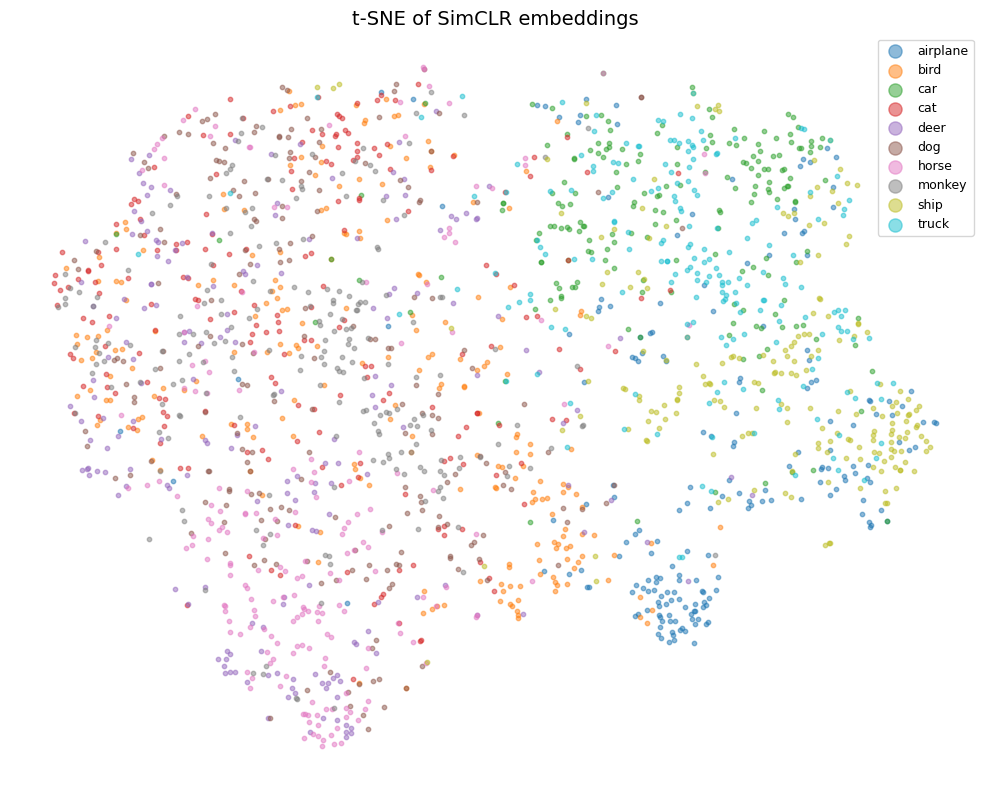

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

STL10_CLASSES = ['airplane','bird','car','cat','deer','dog','horse','monkey','ship','truck']
MAX_TSNE = 500 if SMOKE_TEST else 2000

feats, lbls = [], []
with torch.no_grad():
    for imgs, labels in test_dl:
        feats.append(encoder(imgs.to(DEVICE)).flatten(1).cpu().numpy())
        lbls.extend(labels.tolist())
        if len(lbls) >= MAX_TSNE:
            break

feats = np.concatenate(feats)[:MAX_TSNE]
lbls  = np.array(lbls[:MAX_TSNE])

perplexity = min(30, len(lbls) // 4)
emb = TSNE(n_components=2, random_state=42, perplexity=perplexity).fit_transform(feats)

fig, ax = plt.subplots(figsize=(10, 8))
for i, cls in enumerate(STL10_CLASSES):
    mask = lbls == i
    ax.scatter(emb[mask, 0], emb[mask, 1], label=cls, alpha=0.5, s=10)
ax.legend(markerscale=3, fontsize=9)
ax.set_title('t-SNE of SimCLR embeddings', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/tsne_simclr.png', dpi=150)
plt.show()

## 8. Output

| File | Size | Description |
|---|---|---|
| `checkpoints/simclr_encoder.pt` | 44.8 MB | Encoder weights — input to `fixmatch_sweep.ipynb` |
| `checkpoints/simclr_full.pt` | 46.1 MB | Full model including projection head |

> **Note**: linear probe accuracy of 55.5% was achieved with only 20 epochs.
> Expected to reach ~65–70% with the full 100-epoch run.

In [14]:
for f in sorted(Path('/kaggle/working/').rglob('*.pt')):
    print(f'  {str(f.relative_to("/kaggle/working")):<45} {f.stat().st_size / 1e6:.1f} MB')

  checkpoints/simclr_encoder.pt                 44.8 MB
  checkpoints/simclr_full.pt                    46.1 MB
